=== Agricultural Time Series ===
2021-01-31    2049.671415
2021-02-28    2151.471925
2021-03-31    2351.804656
2021-04-30    2486.286620
2021-05-31    2272.670924
2021-06-30    2163.894283
2021-07-31    2199.600917
2021-08-31    1980.407897
2021-09-30    1768.622801
2021-10-31    1859.828219
2021-11-30    1833.394500
2021-12-31    1973.728863
Freq: ME, Name: monthly_yield, dtype: float64

=== Decomposing Time Series ===


/tmp/ipykernel_6535/4263819186.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2021-01-01', periods=36, freq='M')


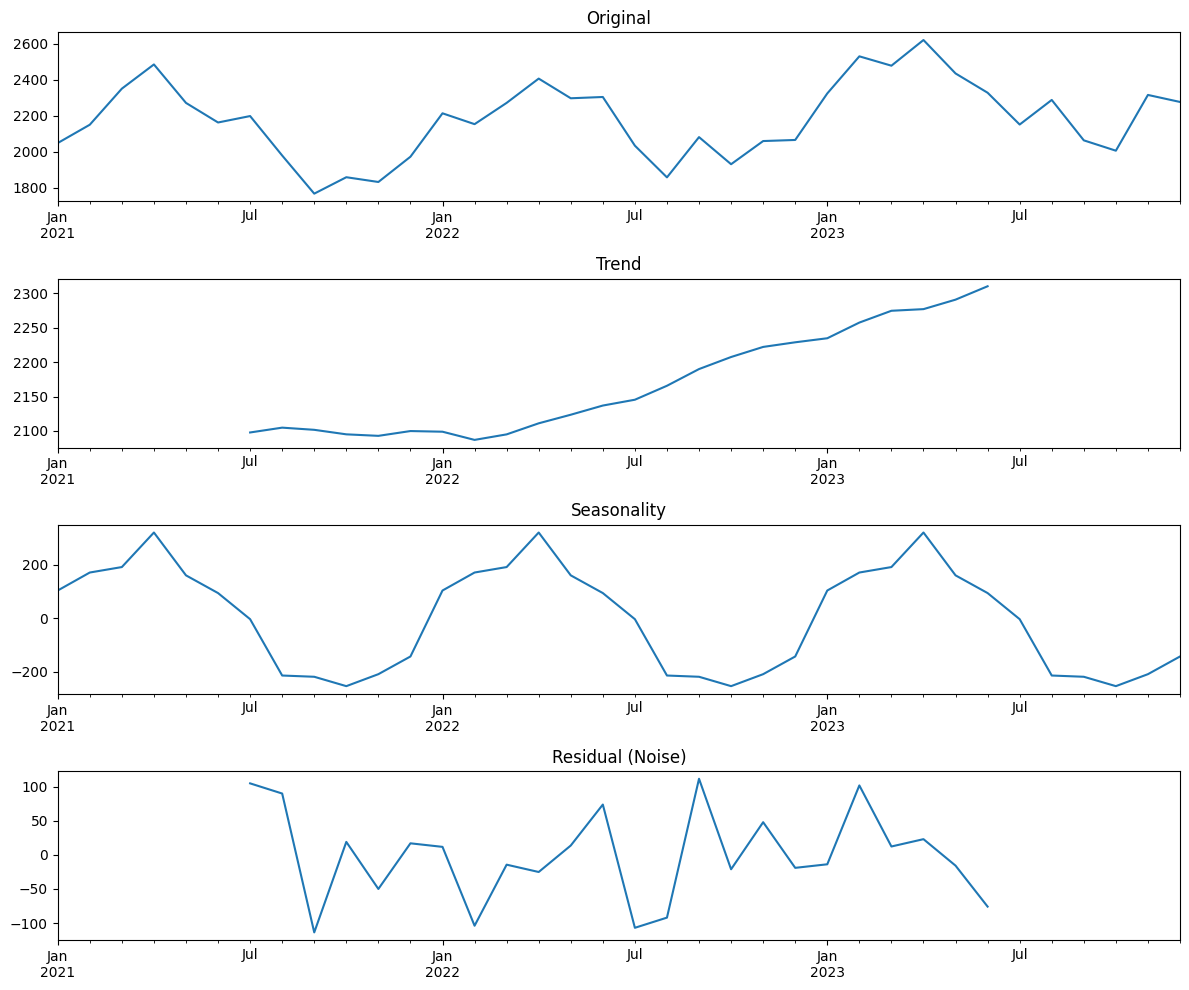


=== Checking Stationarity ===
ADF Statistic: 1.6149
p-value: 0.9979
⚠️ Series is non-stationary - needs differencing
After differencing p-value: 0.4365


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# === CREATE TIME SERIES DATA ===
print("=== Agricultural Time Series ===")

# 3 years of monthly data
dates = pd.date_range('2021-01-01', periods=36, freq='M')

# Create realistic yield pattern
np.random.seed(42)
trend = np.linspace(2000, 2400, 36)  # Increasing trend
seasonality = 300 * np.sin(np.linspace(0, 6*np.pi, 36))  # Seasonal pattern
noise = np.random.normal(0, 100, 36)  # Random noise

yields = trend + seasonality + noise

ts_data = pd.Series(yields, index=dates, name='monthly_yield')
print(ts_data.head(12))

# === DECOMPOSITION ===
print("\n=== Decomposing Time Series ===")
decomposition = seasonal_decompose(ts_data, period=12)

# Visualize components
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], title='Original')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)')

plt.tight_layout()
plt.show()

# === STATIONARITY CHECK ===
print("\n=== Checking Stationarity ===")
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_data.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

if result[1] < 0.05:
    print("✅ Series is stationary")
else:
    print("⚠️ Series is non-stationary - needs differencing")

# Make stationary by differencing
ts_diff = ts_data.diff().dropna()
result2 = adfuller(ts_diff)
print(f'After differencing p-value: {result2[1]:.4f}')
